# Phase 3
## Global Military Spending Analysis

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [ ]:
military_df = pd.read_csv("clean_military.csv")

military_df.head()

,Country Name,Country Code,Year,Military_Spending
0,Aruba,ABW,2000,ABW
1,Africa Eastern and Southern,AFE,2000,5401733241.50712
2,Afghanistan,AFG,2000,AFG
3,Africa Western and Central,AFW,2000,959300982.609088
4,Angola,AGO,2000,583621333.598924


In [ ]:
print("Shape :", military_df.shape)

military_df.info()

Shape : (6650, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Country Name       6650 non-null   object
 1   Country Code       6650 non-null   object
 2   Year               6650 non-null   int64 
 3   Military_Spending  6650 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.9+ KB


In [ ]:
military_df.isnull().sum()

,0
Country Name,0
Country Code,0
Year,0
Military_Spending,0


In [ ]:
military_df["Year"] = military_df["Year"].astype(int)

military_df["Military_Spending"] = pd.to_numeric(
    military_df["Military_Spending"],
    errors="coerce"
)

In [ ]:
military_df.describe()

,Year,Military_Spending
count,6650.000000,5.215000e+03
mean,2012.000000,5.761524e+10
std,7.211645,2.034456e+11
min,2000.000000,0.000000e+00
25%,2006.000000,1.867843e+08
50%,2012.000000,1.647839e+09
75%,2018.000000,1.604584e+10
max,2024.000000,2.651803e+12


In [ ]:
global_spending = (
    military_df.groupby("Year")["Military_Spending"]
    .sum()
    .reset_index()
)

global_spending.head()

,Year,Military_Spending
0,2000,5.342289e+12
1,2001,5.445175e+12
2,2002,5.835471e+12
3,2003,6.879576e+12
4,2004,7.812205e+12


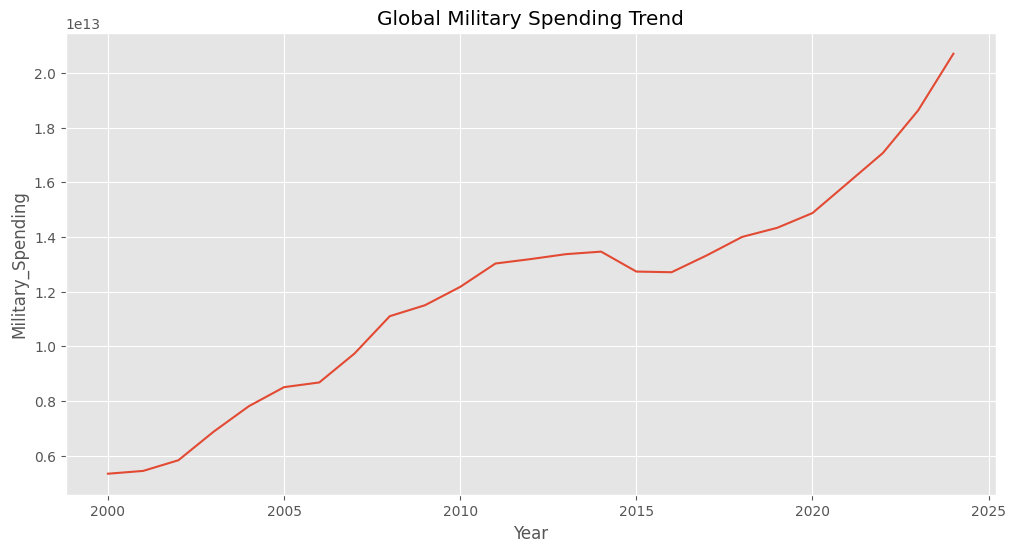

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=global_spending,
    x="Year",
    y="Military_Spending"
)

plt.title("Global Military Spending Trend")

plt.show()

In [ ]:
fig = px.line(
    global_spending,
    x="Year",
    y="Military_Spending",
    title="Global Military Spending Trend"
)

fig.show()

In [ ]:
latest_year = military_df["Year"].max()

latest_data = military_df[
    military_df["Year"] == latest_year
]

latest_data.head()

,Country Name,Country Code,Year,Military_Spending
6384,Aruba,ABW,2024,NaN
6385,Africa Eastern and Southern,AFE,2024,1.365905e+10
6386,Afghanistan,AFG,2024,2.782508e+08
6387,Africa Western and Central,AFW,2024,8.015683e+09
6388,Angola,AGO,2024,9.220508e+08


In [ ]:
top10 = (
    latest_data.sort_values(
        "Military_Spending",
        ascending=False
    )
    .head(10)
)

top10

,Country Name,Country Code,Year,Military_Spending
6643,World,WLD,2024,2.651803e+12
6479,High income,HIC,2024,1.964113e+12
6565,OECD members,OED,2024,1.728774e+12
6582,Post-demographic dividend,PST,2024,1.660856e+12
6554,North America,NAC,2024,1.026656e+12
6635,United States,USA,2024,9.973090e+11
6487,IDA & IBRD total,IBT,2024,8.946387e+11
6486,IBRD only,IBD,2024,8.544038e+11
6449,Europe & Central Asia,ECS,2024,7.190519e+11
6524,Low & middle income,LMY,2024,6.867689e+11


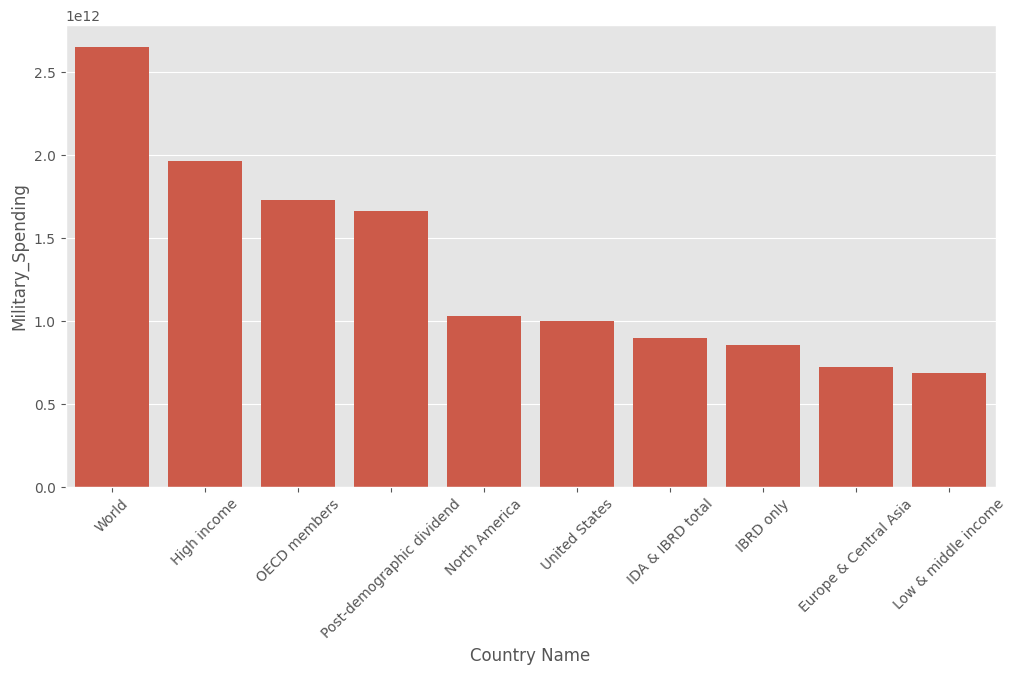

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Country Name",
    y="Military_Spending"
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
fig = px.bar(
    top10,
    x="Country Name",
    y="Military_Spending",
    title="Top 10 Military Spending Countries"
)

fig.show()

In [ ]:
countries = [
    "United States",
    "China",
    "India",
    "Russia"
]

compare = military_df[
    military_df["Country Name"].isin(countries)
]

compare.head()

,Country Name,Country Code,Year,Military_Spending
40,China,CHN,2000,2.223714e+10
109,India,IND,2000,1.428751e+10
251,United States,USA,2000,3.200863e+11
306,China,CHN,2001,2.656146e+10
375,India,IND,2001,1.460064e+10


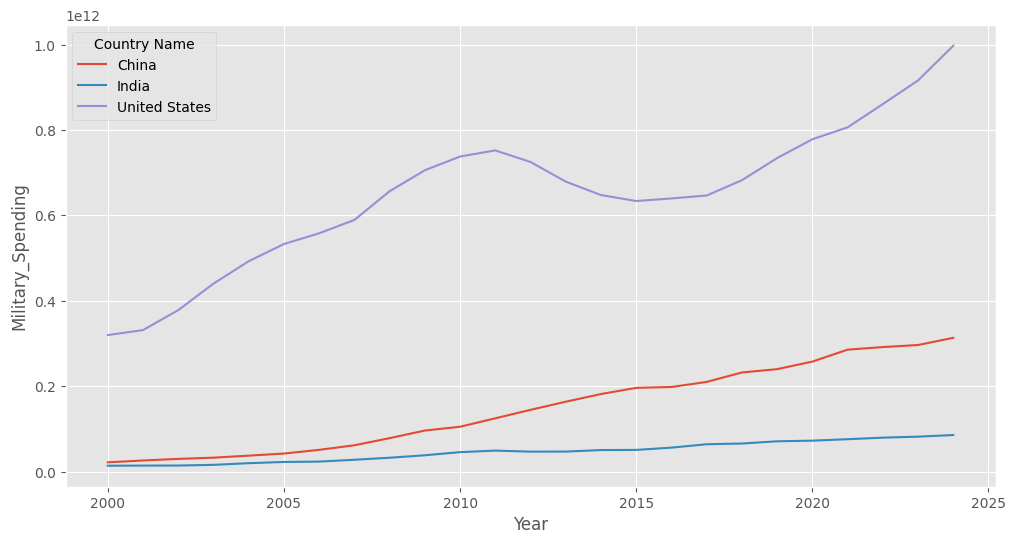

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=compare,
    x="Year",
    y="Military_Spending",
    hue="Country Name"
)

plt.show()

In [ ]:
growth = (
    military_df
    .pivot(
        index="Country Name",
        columns="Year",
        values="Military_Spending"
    )
)

In [ ]:
growth["Growth"] = (
    growth.iloc[:,-1] -
    growth.iloc[:,0]
)

growth = growth.sort_values(
    "Growth",
    ascending=False
)

growth.head(15)

Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Growth
Country Name,,,,,,,,,,,,,,,,,,,,,,,,,,
World,7.423792e+11,7.548841e+11,8.152049e+11,9.520566e+11,1.075236e+12,1.164473e+12,1.205555e+12,1.336860e+12,1.509159e+12,1.563562e+12,1.648692e+12,1.749933e+12,1.757744e+12,1.755100e+12,1.754748e+12,1.651953e+12,1.646773e+12,1.715658e+12,1.806049e+12,1.857409e+12,1.934397e+12,2.072780e+12,2.203187e+12,2.385069e+12,2.651803e+12,1.909424e+12
High income,6.248891e+11,6.326574e+11,6.946152e+11,8.081543e+11,9.076785e+11,9.721574e+11,1.022722e+12,1.116427e+12,1.241616e+12,1.272747e+12,1.322934e+12,1.384807e+12,1.363223e+12,1.329049e+12,1.311926e+12,1.214599e+12,1.208087e+12,1.240367e+12,1.310247e+12,1.361681e+12,1.429489e+12,1.526536e+12,1.610206e+12,1.738806e+12,1.964113e+12,1.339224e+12
OECD members,5.850248e+11,5.875402e+11,6.513082e+11,7.610884e+11,8.531166e+11,9.072300e+11,9.460607e+11,1.024797e+12,1.131462e+12,1.162827e+12,1.200634e+12,1.243129e+12,1.199515e+12,1.146016e+12,1.118223e+12,1.051213e+12,1.065397e+12,1.092726e+12,1.163638e+12,1.221360e+12,1.290810e+12,1.368156e+12,1.402804e+12,1.536190e+12,1.728774e+12,1.143750e+12
Post-demographic dividend,5.608616e+11,5.650918e+11,6.280358e+11,7.363759e+11,8.256592e+11,8.768259e+11,9.134560e+11,9.850846e+11,1.085398e+12,1.119253e+12,1.152003e+12,1.192597e+12,1.148715e+12,1.091467e+12,1.062434e+12,1.002304e+12,1.015119e+12,1.038681e+12,1.105336e+12,1.163508e+12,1.231851e+12,1.306106e+12,1.376988e+12,1.512903e+12,1.660856e+12,1.099994e+12
IDA & IBRD total,1.345015e+11,1.420113e+11,1.427148e+11,1.696611e+11,1.991878e+11,2.324779e+11,2.320830e+11,2.816297e+11,3.437827e+11,3.590467e+11,4.029052e+11,4.556519e+11,4.952321e+11,5.346213e+11,5.486498e+11,5.229729e+11,5.262841e+11,5.630633e+11,5.810557e+11,5.870726e+11,5.940958e+11,6.421629e+11,7.248735e+11,7.982338e+11,8.946387e+11,7.601372e+11
IBRD only,1.155607e+11,1.231743e+11,1.209251e+11,1.340449e+11,1.562414e+11,1.857037e+11,2.160631e+11,2.628198e+11,3.213787e+11,3.362559e+11,3.807098e+11,4.305368e+11,4.691872e+11,5.071441e+11,5.184930e+11,4.921152e+11,4.948889e+11,5.285423e+11,5.473971e+11,5.554184e+11,5.596417e+11,6.024528e+11,6.886500e+11,7.614297e+11,8.544038e+11,7.388431e+11
North America,3.283857e+11,3.401812e+11,3.869585e+11,4.504903e+11,5.043359e+11,5.461911e+11,5.731449e+11,6.070031e+11,6.760981e+11,7.248532e+11,7.573207e+11,7.736817e+11,7.456571e+11,6.977447e+11,6.656426e+11,6.517673e+11,6.576392e+11,6.690226e+11,7.052207e+11,7.567390e+11,8.014800e+11,8.315924e+11,8.862601e+11,9.432424e+11,1.026656e+12,6.982702e+11
United States,3.200863e+11,3.318056e+11,3.784631e+11,4.405321e+11,4.929994e+11,5.332030e+11,5.583350e+11,5.895860e+11,6.567560e+11,7.059170e+11,7.380050e+11,7.522880e+11,7.252050e+11,6.792290e+11,6.477890e+11,6.338296e+11,6.398564e+11,6.467529e+11,6.824914e+11,7.343441e+11,7.783972e+11,8.062302e+11,8.606922e+11,9.160147e+11,9.973090e+11,6.772227e+11
Low & middle income,1.150842e+11,1.199655e+11,1.192294e+11,1.426358e+11,1.657976e+11,1.893086e+11,1.788565e+11,2.157220e+11,2.614943e+11,2.864206e+11,3.214627e+11,3.612152e+11,3.890403e+11,4.195061e+11,4.408528e+11,4.365912e+11,4.379778e+11,4.726490e+11,4.945211e+11,4.951874e+11,5.041513e+11,5.446463e+11,5.911913e+11,6.448500e+11,6.867689e+11,5.716847e+11


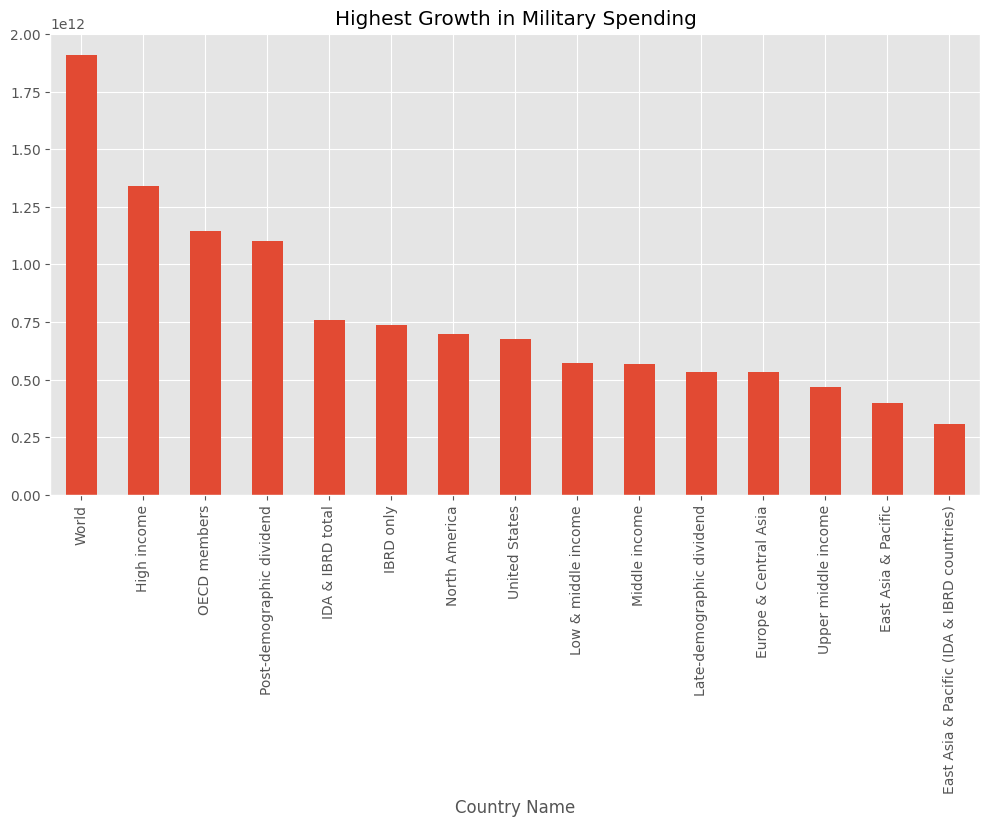

In [ ]:
growth["Growth"].head(15).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Highest Growth in Military Spending")

plt.show()

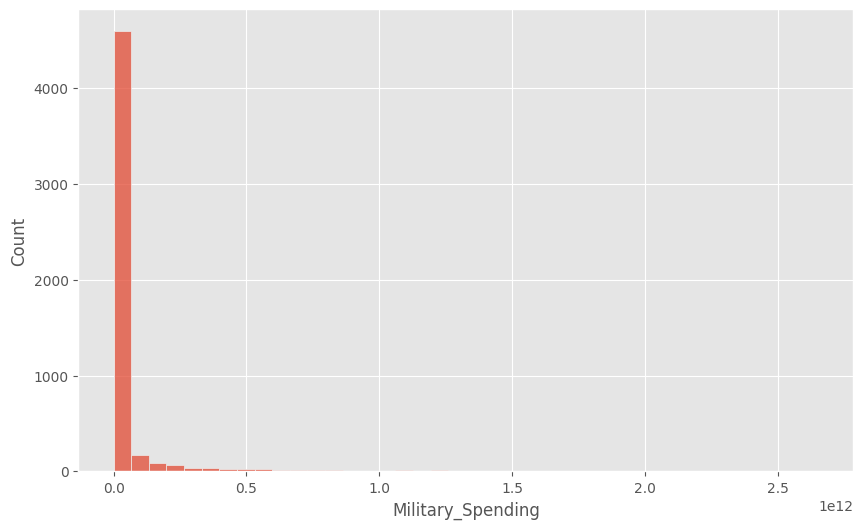

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    military_df["Military_Spending"],
    bins=40
)

plt.show()

In [ ]:
print(f"""

Latest Year :
{latest_year}

Highest Spending Country :

{top10.iloc[0]['Country Name']}

Highest Spending :

{top10.iloc[0]['Military_Spending']:.2f}

Countries Available :

{military_df['Country Name'].nunique()}

Years Covered :

{military_df['Year'].min()} - {military_df['Year'].max()}

""")



Latest Year :
2024

Highest Spending Country :

World

Highest Spending :

2651803473255.19

Countries Available :

266

Years Covered :

2000 - 2024




In [ ]:
global_spending.to_csv(
    "global_military_trend.csv",
    index=False
)

top10.to_csv(
    "top10_military.csv",
    index=False
)

print("Phase 3 Completed Successfully")

Phase 3 Completed Successfully
